# Case 2: Figure Reproduction Notebook

This notebook is for loading precomputed MOSAIC outputs and generating case-study figures only.

For full analysis/statistical workflow details, see the analysis pipeline and mixed effects models notebooks.

In [1]:
# --- 1. Load Precomputed Data ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root
ROOT = Path.cwd().parents[1] if Path.cwd().name == "MOSAIC" else Path.cwd()

# Figure sources
linear_file = ROOT / ".." / "linear_results" / "linear_arms_mag.csv"
xcorr_file = ROOT / ".." / "linear_results" / "xcorr_body_velmag.csv"
rqa_file = ROOT / ".." / "crqa_results" / "crqa_arms_mag.csv"

if not linear_file.exists():
    raise FileNotFoundError(f"Missing linear figure source: {linear_file}")
if not xcorr_file.exists():
    raise FileNotFoundError(f"Missing xcorr figure source: {xcorr_file}")
if not rqa_file.exists():
    raise FileNotFoundError(f"Missing RQA figure source: {rqa_file}")

lin_df = pd.read_csv(linear_file)
xcorr_df = pd.read_csv(xcorr_file)
rqa_wide = pd.read_csv(rqa_file)

conditions = ['Office', 'Cafe', 'Food', 'Party']

lin_df['Condition'] = pd.Categorical(
    lin_df['Condition'].astype(str).str.strip(),
    categories=conditions,
    ordered=True,
)
xcorr_df['Condition'] = pd.Categorical(
    xcorr_df['Condition'].astype(str).str.strip(),
    categories=conditions,
    ordered=True,
)
rqa_wide['Condition'] = pd.Categorical(
    rqa_wide['Condition'].astype(str).str.strip(),
    categories=conditions,
    ordered=True,
)

print(f"Loaded Linear shape: {lin_df.shape}")
print(f"Loaded XCorr shape: {xcorr_df.shape}")
print(f"Loaded RQA shape: {rqa_wide.shape}")


Loaded Linear shape: (6344, 17)
Loaded XCorr shape: (3114, 15)
Loaded RQA shape: (2462, 17)


C:\Users\Cathy\AppData\Local\Temp\ipykernel_44804\761644078.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=c, edgecolor='black', linewidth=2, label=l)
C:\Users\Cathy\AppData\Local\Temp\ipykernel_44804\761644078.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['', '', '', ''])
C:\Users\Cathy\AppData\Local\Temp\ipykernel_44804\761644078.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['', '', '', ''])


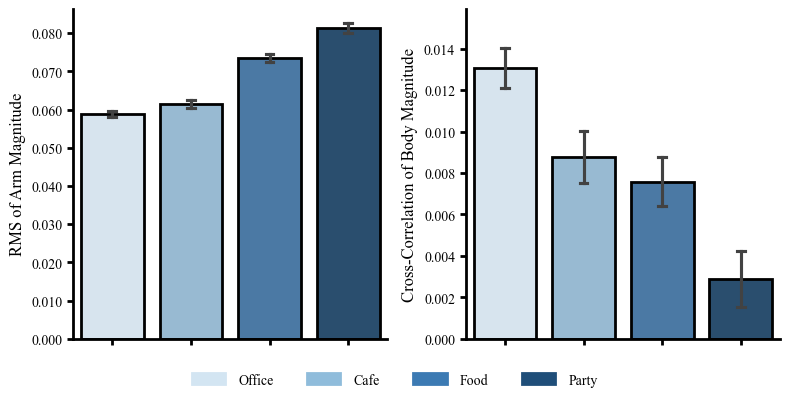

C:\Users\Cathy\AppData\Local\Temp\ipykernel_44804\761644078.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=c, edgecolor='black', linewidth=2, label=l)
C:\Users\Cathy\AppData\Local\Temp\ipykernel_44804\761644078.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['', '', '', ''])
C:\Users\Cathy\AppData\Local\Temp\ipykernel_44804\761644078.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['', '', '', ''])


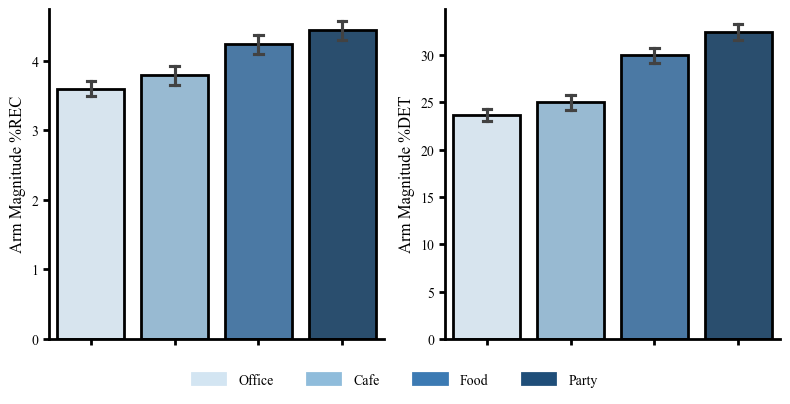

In [2]:
# --- 2. CSV-Driven Plots Across Conditions (Split Figures) ---
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
import numpy as np

plt.style.use('default')

# Windows-safe: use installed font name first
plt.rcParams['font.family'] = ['Times New Roman', 'serif']

# Optional: explicitly add Windows Times New Roman file if present
tnr_path = Path(r'C:\Windows\Fonts\times.ttf')
tnr_name = 'Times New Roman'
if tnr_path.exists():
    fm.fontManager.addfont(str(tnr_path))
    tnr_fp = fm.FontProperties(fname=str(tnr_path))
    tnr_name = tnr_fp.get_name()
else:
    tnr_fp = fm.FontProperties(family=tnr_name)

# Apply font settings AFTER style so they are not overwritten
mpl.rcParams['font.family'] = [tnr_name]
mpl.rcParams['font.serif'] = [tnr_name, 'Times', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['svg.fonttype'] = 'path'
mpl.rcParams['pdf.fonttype'] = 42

colors = ['#d3e5f2', '#8fbcdb', '#3c7ab3', '#1f4e79']

def make_two_panel_figure(plot_specs, out_stem):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes = axes.flatten()

    legend_patches = [
        mpatches.Patch(color=c, edgecolor='black', linewidth=2, label=l)
        for c, l in zip(colors, conditions)
    ]

    for (df_plot, metric, ylab), ax in zip(plot_specs, axes):
        if metric not in df_plot.columns:
            ax.text(0.5, 0.5, f'Missing:\n{metric}', ha='center', va='center', fontproperties=tnr_fp)
            ax.set_axis_off()
            continue

        sns.barplot(
            data=df_plot,
            x='Condition',
            y=metric,
            order=conditions,
            hue='Condition',
            hue_order=conditions,
            palette=colors,
            legend=False,
            estimator=np.mean,
            errorbar=('se', 1),   
            n_boot=0,             
            ax=ax,
            edgecolor='black',
            linewidth=2,
            capsize=0.1,
        )

        stats = (
            df_plot.loc[df_plot['Condition'].isin(conditions), ['Condition', metric]]
            .dropna()
            .groupby('Condition', observed=True)[metric]
            .agg(['mean', 'sem'])
            .reindex(conditions)
        )
        stats['sem'] = stats['sem'].fillna(0)

        if stats['mean'].notna().any():
            low = (stats['mean'] - stats['sem']).min()
            high = (stats['mean'] + stats['sem']).max()
            span = max(high - low, 1e-6)
            bottom = 0 if low >= 0 else low - 0.2 * span
            ax.set_ylim(bottom, high + 0.15 * span)

        ax.set_ylabel(ylab, fontsize=12, fontproperties=tnr_fp)
        if out_stem == 'linear_summary_mosaic':
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
        ax.set_xlabel('')
        ax.set_xticklabels(['', '', '', ''])
        ax.tick_params(axis='x', length=4, width=2)
        ax.tick_params(axis='y', length=4, width=2)

        for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
            tick_label.set_fontproperties(tnr_fp)

        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)

        for line in ax.lines:
            line.set_clip_on(False)

    legend = fig.legend(
        handles=legend_patches,
        labels=conditions,
        loc='lower center',
        ncol=4,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=12,
        frameon=False,
    )
    for txt in legend.get_texts():
        txt.set_fontproperties(tnr_fp)

    plt.tight_layout(rect=[0, 0.08, 1, 1])

    out_png = ROOT / 'figs' / f'{out_stem}.png'
    out_pdf = ROOT / 'figs' / f'{out_stem}.pdf'
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.savefig(out_pdf, dpi=300, bbox_inches='tight')
    plt.show()

# Figure 1: Linear metrics (RMS + Cross-Correlation)
make_two_panel_figure(
    [
        (lin_df, 'RMS', 'RMS of Arm Magnitude'),
        (xcorr_df, 'XCorr_VelMag_r0', 'Cross-Correlation of Body Magnitude'),
    ],
    out_stem='linear_summary_mosaic',
)

# Figure 2: RQA metrics (%REC + %DET)
make_two_panel_figure(
    [
        (rqa_wide, 'CRQA_REC', 'Arm Magnitude %REC'),
        (rqa_wide, 'CRQA_DET', 'Arm Magnitude %DET'),
    ],
    out_stem='rqa_summary_mosaic',
)
